In [126]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scienceplots
import numpy as np
import shap

In [127]:
plt.style.use(['science', 'notebook', 'grid'])

In [145]:
X_test = joblib.load("../data/splits/no_score/X_test.pkl")
y_test = joblib.load("../data/splits/no_score/y_test.pkl")
features = X_test.columns.tolist()

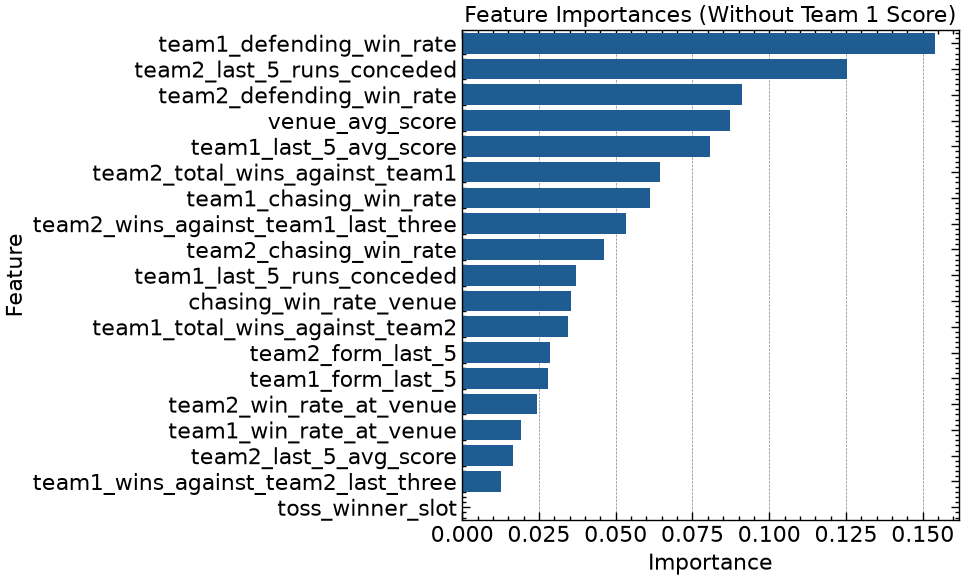

In [151]:
best_model = joblib.load("../models/production/no_score/best_model.pkl")

model = best_model.named_steps["classifier"]
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importances (Without Team 1 Score)")
plt.tight_layout()
plt.show()

### Key Observations from the Feature Importance Plot
- __team1_defending_win_rate__ is the most influential feature.
- Defensive and bowling-related statistics dominate the top-ranked features.
- Venue characteristics contribute substantially to prediction performance.
- Recent form and head-to-head statistics provide moderate predictive information.
- Toss outcome has minimal impact on the model.

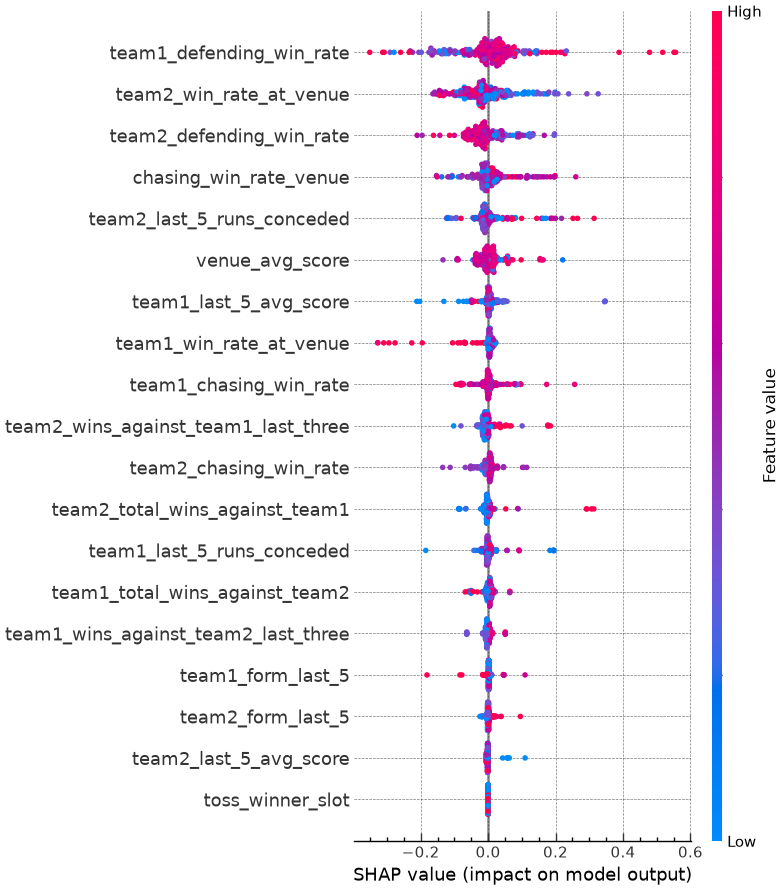

In [152]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values[:, :,  1],
    X_test,
    feature_names = X_test.columns
)

### Key observations from the SHAP Summary Plot
- __team1_defending_win_rate__ has the largest overall impact on predictions.
- Venue-related and defensive statistics consistently influence model output.
- Lower-ranked features have SHAP values clustered near zero.
- Feature effects depend on interactions with other variables rather than simple linear relationships.

In [153]:
shap.initjs()

sample_idx = 0

shap.plots.force(
    base_value=shap_values.base_values[sample_idx, 1],
    shap_values=shap_values.values[sample_idx, :, 1],
    features=X_test.iloc[sample_idx],
    feature_names=X_test.columns,
)

### Key observations from the SHAP Force Plot
- Baseline probability is approximately **0.45**, while the final prediction is approximately **0.38**.
- Negative feature contributions dominate the prediction.
- Defensive performance and venue-related statistics exert the strongest influence.
- Positive contributions from head-to-head records and venue win rate are comparatively smaller.
- The prediction results from the combined effect of multiple interacting features rather than any single statistic.

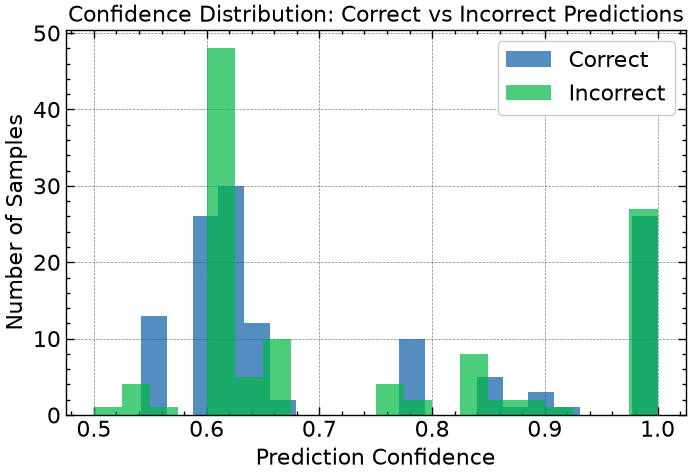

In [154]:
probs = model.predict_proba(X_test)
confidence = np.max(probs, axis=1)
predictions = model.predict(X_test)

correct = predictions == y_test.iloc[:,0]

plt.figure(figsize=(8, 5))

plt.hist(
    confidence[correct],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    confidence[~correct],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.legend()

plt.show()

The confidence distribution indicates that the classifier exhibits poor discrimination between correct and incorrect predictions. Both classes share similar confidence ranges (approximately 0.58–0.65), resulting in substantial overlap. Furthermore, several incorrect predictions are assigned extremely high confidence (close to 1.0), indicating that the model is overconfident and its predicted probabilities are poorly calibrated. These observations are consistent with the model's low classification accuracy of approximately 51–53%, suggesting that prediction confidence alone is not a reliable indicator of correctness.

In [158]:
X_test = joblib.load("../data/splits/with_score/X_test.pkl")
y_test = joblib.load("../data/splits/with_score/y_test.pkl")
features = X_test.columns.tolist()

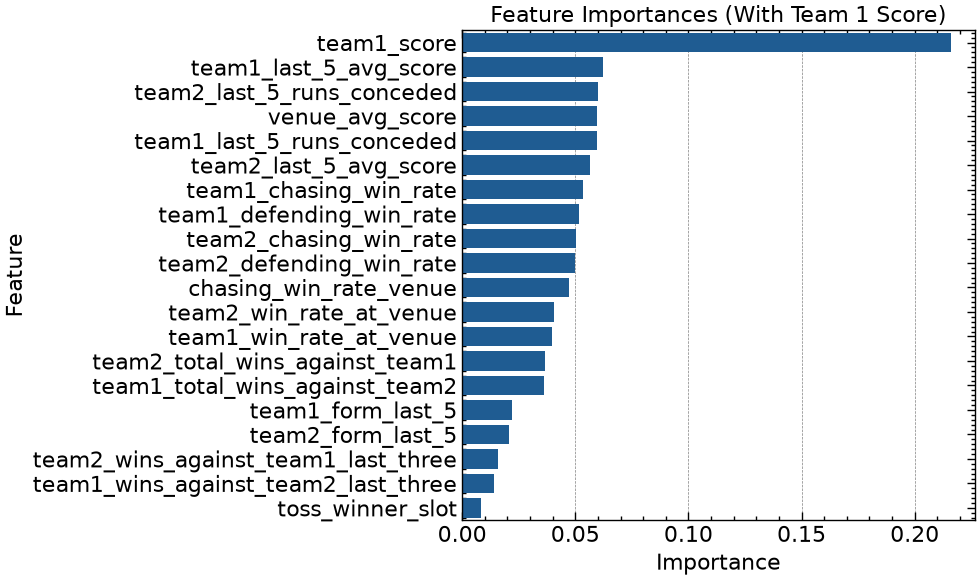

In [159]:
best_model = joblib.load("../models/production/with_score/best_model.pkl")

model = best_model.named_steps["classifier"]
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importances (With Team 1 Score)")
plt.tight_layout()
plt.show()

### Key observations from the Feature Importance Plot

- **team1_score** is the dominant predictor with the highest feature importance.
- Recent batting and bowling statistics remain useful supporting features.
- Venue characteristics continue to contribute meaningfully to prediction performance.
- Historical win rates become less influential once the actual Team 1 score is included.
- Toss outcome remains the least informative feature.

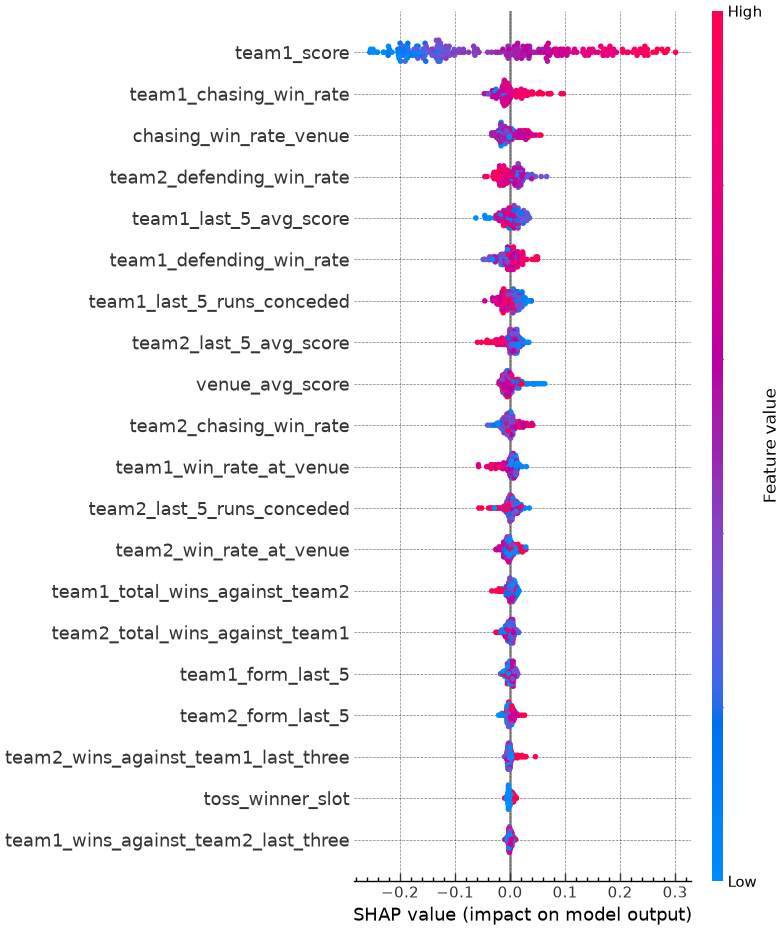

In [160]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values[:, :,  1],
    X_test,
    feature_names = X_test.columns
)

### Key observations from the SHAP Summary Plot

- **team1_score** has the largest impact on model output.
- Higher Team 1 scores consistently increase the predicted probability of winning.
- Historical team strengths provide supplementary predictive information.
- Recent form and toss outcome contribute minimally.
- The SHAP distribution indicates a strong and interpretable relationship between Team 1's score and prediction outcome

In [161]:
shap.initjs()

sample_idx = 0

shap.plots.force(
    base_value=shap_values.base_values[sample_idx, 1],
    shap_values=shap_values.values[sample_idx, :, 1],
    features=X_test.iloc[sample_idx],
    feature_names=X_test.columns,
)

### Key observations from SHAP Force Plot

- Baseline probability is approximately **0.46**, while the final predicted probability decreases to approximately **0.24.**
- **Team 1's score** (126) is the strongest factor reducing the predicted probability.
- Venue characteristics and historical performance further reinforce the negative prediction.
- Positive contributions from chasing ability and the opponent's recent bowling performance are comparatively small.
- The prediction reflects the combined influence of multiple features, with Team 1's score exerting the largest effect.

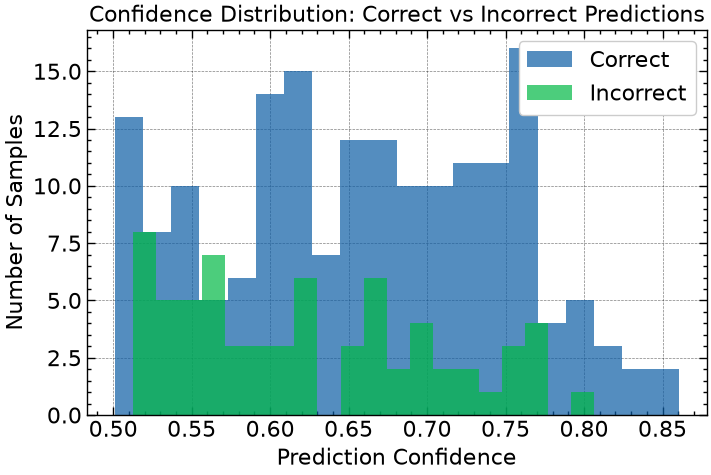

In [162]:
probs = model.predict_proba(X_test)
confidence = np.max(probs, axis=1)
predictions = model.predict(X_test)

correct = predictions == y_test.iloc[:,0]

plt.figure(figsize=(8, 5))

plt.hist(
    confidence[correct],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    confidence[~correct],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.legend()

plt.show()

The confidence distribution demonstrates that incorporating Team 1's score significantly improves the model's prediction reliability. Correct predictions dominate the higher confidence range (approximately 0.75–0.85), while incorrect predictions are primarily concentrated at lower confidence levels (0.50–0.70). Compared with the baseline model, the overlap between correct and incorrect confidence distributions is reduced, and the model exhibits fewer highly confident misclassifications. These observations suggest that Team 1's score is a highly informative feature, improving both the discriminative ability and confidence calibration of the classifier.

## Key Takeaways

- **Including Team 1's score significantly improved model interpretability**, making it the most influential feature in prediction.
- **Without Team 1's score, the model relied primarily on historical team performance, bowling statistics, and venue characteristics** to estimate match outcomes.
- **Historical features became secondary predictors** once the actual first-innings score was available, serving mainly to refine predictions.
- **SHAP analyses showed consistent agreement with feature importance rankings** in both models, confirming the reliability of the explainability results.
- **The findings align with cricket domain knowledge**, where the first-innings score is the strongest indicator of match outcome, while historical and venue-based statistics provide valuable contextual support.